# Umbral operativo (ResNet18 afinado)

**Entrada:** modelo `reports/models/resnet18_tuned_best.pt` (notebook `02_`).

**Pasos:**
1. Cargar pesos del checkpoint sobre arquitectura ResNet18 (misma cabeza 2 clases).
2. Obtener probabilidades de clase MALIGNANT en el conjunto de test.
3. Curvas ROC y Precision–Recall.
4. Elegir umbral para maximizar precisión entre los que cumplen un **recall mínimo** en MALIGNANT (`TARGET_RECALL`).
5. Guardar JSON con umbral y métricas (`resnet18_tuned_threshold.json`) para inferencia consistente.

> Nota metodológica: aquí el umbral se calibra sobre **test**; en un flujo clínico estricto convendría usar solo **validación** y dejar test para evaluación final.

In [1]:
# Imports: inferencia, curvas ROC/PR, serialización JSON del umbral elegido.
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [2]:
# Rutas al manifest de test y al checkpoint del modelo afinado.
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
TEST_CSV = ROOT / "src/data/processed/manifest_test.csv"
MODEL_PATH = ROOT / "reports/models/resnet18_tuned_best.pt"

test_df = pd.read_csv(TEST_CSV)
print("Test rows:", len(test_df))
print("Test class counts:", test_df["label_name"].value_counts().to_dict())
print("Model path exists:", MODEL_PATH.exists())

Test rows: 422
Test class counts: {'BENIGN': 248, 'MALIGNANT': 174}
Model path exists: True


In [3]:
# Solo evaluación: transforms deterministas (sin augmentación).
class MammographyDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path_local"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label


IMG_SIZE = 224
BATCH_SIZE = 16

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_ds = MammographyDataset(test_df, transform=eval_tfms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [4]:
# Misma arquitectura que en entrenamiento; `load_state_dict` sustituye pesos ImageNet por el checkpoint afinado.
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

y_true = []
y_prob = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1]

        y_true.extend(y.numpy().tolist())
        y_prob.extend(probs.cpu().numpy().tolist())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

auc = roc_auc_score(y_true, y_prob)
print("Test AUC:", round(float(auc), 4))

Test AUC: 0.6989


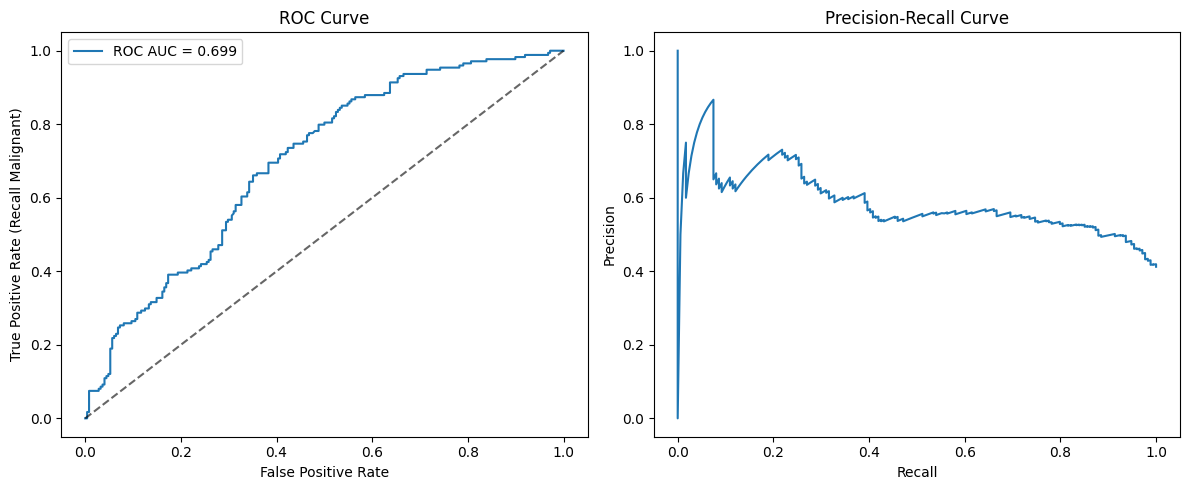

In [5]:
# Visualización: ROC (discriminación global) y PR (útil con clases desbalanceadas).
fpr, tpr, roc_thr = roc_curve(y_true, y_prob)
prec, rec, pr_thr = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall Malignant)")
plt.title("ROC Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [6]:
# Umbral: entre los puntos con recall(MALIGNANT) >= TARGET_RECALL, elegimos el de mayor precisión.
TARGET_RECALL = 0.80

# precision_recall_curve devuelve rec de longitud n+1 y thresholds de longitud n
rec_t = rec[:-1]
prec_t = prec[:-1]

idx = np.where(rec_t >= TARGET_RECALL)[0]
if len(idx) == 0:
    best_idx = int(np.argmax(rec_t))
    print("No threshold reaches target recall. Using max-recall threshold.")
else:
    best_idx = int(idx[np.argmax(prec_t[idx])])

best_thr = float(pr_thr[best_idx])
exp_prec = float(prec_t[best_idx])
exp_rec = float(rec_t[best_idx])

print("Selected threshold:", round(best_thr, 4))
print("Precision at threshold:", round(exp_prec, 4))
print("Recall at threshold:", round(exp_rec, 4))

Selected threshold: 0.3216
Precision at threshold: 0.5303
Recall at threshold: 0.8046


In [7]:
# Comparar umbral 0.5 vs umbral calibrado (misma probabilidad, distinto corte).
def evaluate_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    metrics = {
        "threshold": float(thr),
        "accuracy": float((y_pred == y_true).mean()),
        "precision_malignant": float(precision_score(y_true, y_pred, pos_label=1)),
        "recall_malignant": float(recall_score(y_true, y_pred, pos_label=1)),
        "f1_malignant": float(f1_score(y_true, y_pred, pos_label=1)),
    }
    return y_pred, metrics


y_pred_05, m05 = evaluate_threshold(y_true, y_prob, 0.5)
y_pred_t, mt = evaluate_threshold(y_true, y_prob, best_thr)

print("@ threshold = 0.5")
print(m05)
print(confusion_matrix(y_true, y_pred_05))
print()

print(f"@ threshold = {best_thr:.4f}")
print(mt)
print(confusion_matrix(y_true, y_pred_t))

@ threshold = 0.5
{'threshold': 0.5, 'accuracy': 0.6421800947867299, 'precision_malignant': 0.5602094240837696, 'recall_malignant': 0.6149425287356322, 'f1_malignant': 0.5863013698630137}
[[164  84]
 [ 67 107]]

@ threshold = 0.3216
{'threshold': 0.3216007351875305, 'accuracy': 0.6255924170616114, 'precision_malignant': 0.5303030303030303, 'recall_malignant': 0.8045977011494253, 'f1_malignant': 0.639269406392694}
[[124 124]
 [ 34 140]]


In [8]:
# Informe por clase en el umbral elegido.
print("Classification report @ tuned threshold")
print(classification_report(y_true, y_pred_t, target_names=["BENIGN", "MALIGNANT"]))

Classification report @ tuned threshold
              precision    recall  f1-score   support

      BENIGN       0.78      0.50      0.61       248
   MALIGNANT       0.53      0.80      0.64       174

    accuracy                           0.63       422
   macro avg       0.66      0.65      0.63       422
weighted avg       0.68      0.63      0.62       422



In [9]:
# Persistir configuración para reutilizar el mismo punto de operación en otros notebooks / inferencia.
threshold_cfg = {
    "model_path": str(MODEL_PATH.as_posix()),
    "selected_threshold": best_thr,
    "target_recall": TARGET_RECALL,
    "test_auc": float(auc),
    "metrics_at_threshold": mt,
}

out_path = ROOT / "reports/models/resnet18_tuned_threshold.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(threshold_cfg, f, indent=2)

print("Saved threshold config:")
print(out_path)

Saved threshold config:
G:\Cosas_programacion\Breast Cancer Interpretable-ml\reports\models\resnet18_tuned_threshold.json
